# 03. TS マップ (localization) (目標 4)

各グリッド位置に試験点源を置きフラックスだけ最尤化し、
$\mathrm{TS}(l)=2[\log L(\text{源あり})-\log L(\text{源なし})]$ を並べます。
山が源の位置、$\sqrt{\mathrm{TS}}$ が概ねの検出有意度。

In [1]:
import logging; logging.disable(logging.INFO)
import numpy as np
import matplotlib.pyplot as plt

from astromodels import Model, PointSource, Powerlaw
from Toy3MLplugin import simulate_counts, BackgroundComponent, ts_map_1d, make_folded_response
from Toy3MLplugin.toy.scanner import ToyScanLike, toy_observation

E_EDGES = np.array([2.0, 10.0]); FOV_SIGMA = 3.0
def fixed(name, l, K):
    s = PointSource(name, l=l, b=0.0, spectral_shape=Powerlaw(K=K, index=-2.0))
    s.spectrum.main.Powerlaw.index.free = False
    s.position.l.free = False; s.position.b.free = False
    return s

R, sky_l, orbit = make_folded_response((0, 30), n_t=500, dwell=80.0,
                                       energy_edges=E_EDGES, fov_sigma_deg=FOV_SIGMA)
n = orbit["l"].size
bkg = lambda: [BackgroundComponent("inst", np.ones(n), value=4.0)]
truth = Model(fixed("A", 7.0, 0.5), fixed("B", 20.0, 0.25))
sim = ToyScanLike("t", toy_observation(np.zeros(n), R, sky_l, orbit), E_EDGES, backgrounds=bkg())
data = simulate_counts(sim, truth, np.random.default_rng(4))
plugin = ToyScanLike("t", toy_observation(data, R, sky_l, orbit), E_EDGES, backgrounds=bkg())

18:48:30 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=3541887;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=3541888;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=3541894;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=3541895;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=3541902;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=3541903;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

18:48:30 WARNING   WARNINGs here are NOT errors                                                      ]8;id=3541910;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=3541911;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#45\45]8;;\

         WARNING   but are inform you about optional packages that can be installed                  ]8;id=3541917;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=3541918;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#46\46]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=3541953;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=3541954;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=3541961;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=3541962;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=3541968;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=3541969;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=3541974;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=3541975;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=3541980;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=3541981;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

In [2]:
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

### TS マップを計算してプロット

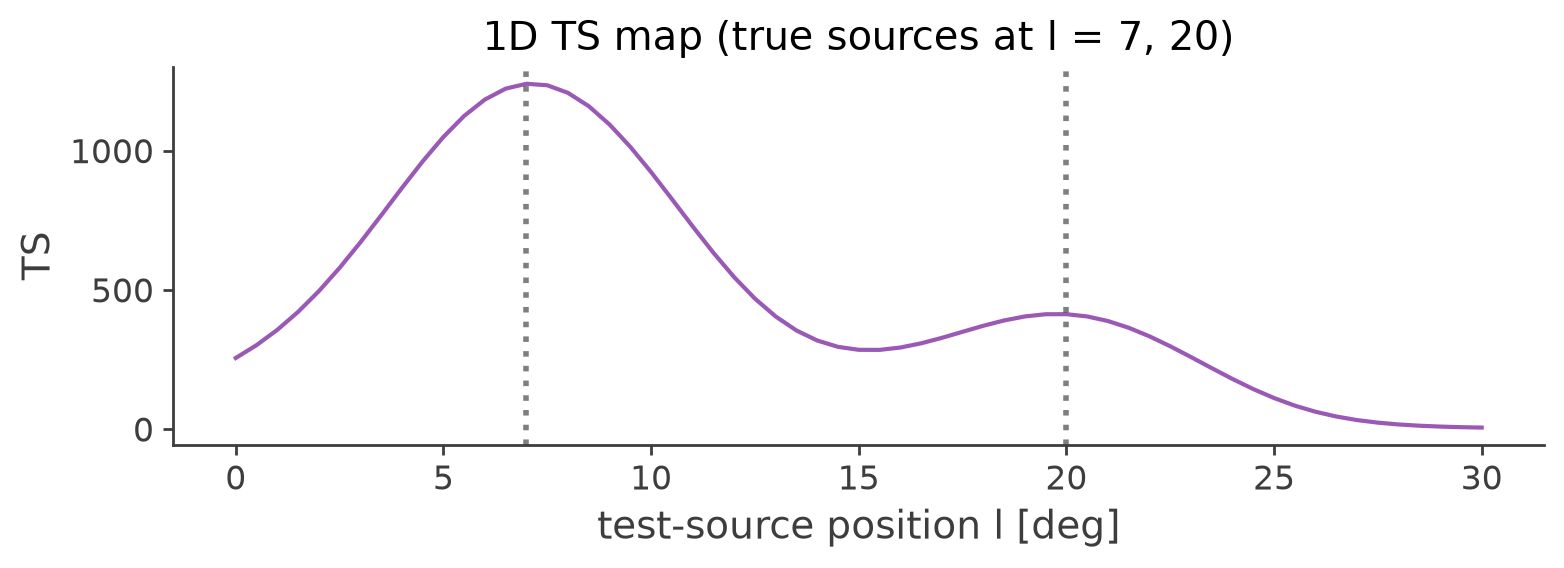

peak at l=  7.0   TS=  1240   ~35.2 sigma
peak at l= 20.0   TS=   412   ~20.3 sigma


In [3]:
grid = np.arange(0, 30.01, 0.5)
gl, ts = ts_map_1d(plugin, grid)     # base_sources=None → null は背景のみ

plt.figure(figsize=(8,3))
plt.plot(gl, ts, lw=1.5)
for l0 in (7.0, 20.0): plt.axvline(l0, color="k", ls=":", alpha=0.5)
plt.xlabel("test-source position l [deg]"); plt.ylabel("TS")
plt.title("1D TS map (true sources at l = 7, 20)"); plt.tight_layout(); plt.show()

peaks = [i for i in range(1,len(ts)-1) if ts[i]>ts[i-1] and ts[i]>ts[i+1] and ts[i]>ts.max()*0.1]
for i in peaks:
    print(f"peak at l={gl[i]:5.1f}   TS={ts[i]:6.0f}   ~{ts[i]**0.5:4.1f} sigma")